<a href="https://colab.research.google.com/github/shirohigexe/practicas_HO_ML/blob/main/CustomerFligth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A continuación, como ejercicio de practica para reafirmar conocimientos, aplicaremos lo aprendido en un caso proximo a la realidad:

## PROBLEMA CLAVE:
la idea es predecir la cancelación de la tarjeta de credito del cliente.

## CONTEXTO:
para un banco es entre 5 y 25 veces más dificil atraer clientes nuevos que retener a los que ya están afiliados, por lo que cuando un cliente llama a cancelar su cuenta, que para este momento es demasiado tarde, el banco pierde por partida doble, ya que deja de persibir comiciones e intereses provenientes de esta cuenta


#Setup

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshigoyal7/credit-card-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customers' dataset.
Path to dataset files: /kaggle/input/credit-card-customers


In [ ]:
import pandas as pd

df_0 = pd.read_csv(path + "/BankChurners.csv")

Colimns_to_drop = [df_0.columns[-1], df_0.columns[-2]] #Columnas eliminadas para no intervenir en el desarrollo del ejercicio personal
df = df_0.drop(columns=Colimns_to_drop)
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


##variables demografica:
Para manejo de algunas variables demograficas, se convertirán en variables numericas

Con una asignación por niveles, conservaremos la 'distancia' para el/los modelos, en este caso, en la categoria 'Income_Category':
* 'Unknown': 0
* 'Less than $40K': 1

* '$40K - $60K': 2
* '$60K - $80K': 3
* '$80K - $120K': 4
* '$120K +': 5



In [ ]:
df['Income_Category'].value_counts()

,count
Income_Category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
Unknown,1112
$120K +,727


In [ ]:
mapping = {'Unknown': 0, 'Less than $40K': 1, '$40K - $60K': 2, '$60K - $80K': 3, '$80K - $120K': 4, '$120K +': 5}
df['Income_Category'] = df['Income_Category'].map(mapping)

df['Income_Category'].value_counts()

,count
Income_Category,
1,3561
2,1790
4,1535
3,1402
0,1112
5,727


de manera similar para 'Card_category'

In [ ]:
df['Card_Category'].value_counts()

,count
Card_Category,
Blue,9436
Silver,555
Gold,116
Platinum,20


In [ ]:
mapping = {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
df['Card_Category'] = df['Card_Category'].map(mapping)

df['Card_Category'].value_counts()

,count
Card_Category,
0,9436
1,555
2,116
3,20


#Dataset

| # | Columna | Descripción |
| :--- | :--- | :--- |
| 1 | **CLIENTNUM** | Número de cliente. Identificador único para el cliente titular de la cuenta. |
| 2 | **Attrition_Flag** | Variable interna de evento (abandono) - si la cuenta está cerrada es 1, de lo contrario es 0. |
| 3 | **Customer_Age** | Variable demográfica - Edad del cliente en años. |
| 4 | **Gender** | Variable demográfica - Género: M=Masculino, F=Femenino. |
| 5 | **Dependent_count** | Variable demográfica - Número de dependientes (personas a cargo económicamente). |
| 6 | **Education_Level** | Variable demográfica - Nivel educativo del titular de la cuenta (ej: secundaria, graduado universitario, etc.). |
| 7 | **Marital_Status** | Variable demográfica - Estado civil: Casado, Soltero, Divorciado, Desconocido. |
| 8 | **Income_Category** | Variable demográfica - Categoría de ingresos anuales del titular (< $40K, $40K - 60K, $60K - $80K, $80K-$120K, > $120K, Desconocido). |
| 9 | **Card_Category** | Variable de producto - Tipo de Tarjeta (Azul, Plata, Oro, Platino). |
| 10 | **Months_on_book** | Período de relación con el banco (en meses). Antigüedad del cliente. |
| 11 | **Total_Relationship_Count** | Número total de productos que el cliente tiene con el banco. |
| 12 | **Months_Inactive_12_mon** | Número de meses inactivo durante los últimos 12 meses. |
| 13 | **Contacts_Count_12_mon** | Número de contactos (interacciones con el banco) en los últimos 12 meses. |
| 14 | **Credit_Limit** | Límite de crédito asignado a la Tarjeta de Crédito. |
| 15 | **Total_Revolving_Bal** | Saldo rotativo total en la tarjeta (la deuda pendiente que no se pagó a fin de mes y genera intereses). |
| 16 | **Avg_Open_To_Buy** | Línea de crédito disponible para comprar (Promedio de los últimos 12 meses). |
| 17 | **Total_Amt_Chng_Q4_Q1** | Cambio en el monto de transacciones (Comparación del Trimestre 4 frente al Trimestre 1). |
| 18 | **Total_Trans_Amt** | Monto total gastado en transacciones (Últimos 12 meses). |
| 19 | **Total_Trans_Ct** | Cantidad total de transacciones realizadas (Últimos 12 meses). |
| 20 | **Total_Ct_Chng_Q4_Q1** | Cambio en la cantidad de transacciones (Comparación del Trimestre 4 frente al Trimestre 1). |
| 21 | **Avg_Utilization_Ratio** | Ratio promedio de utilización de la tarjeta (Porcentaje del límite de crédito que el cliente está utilizando). |

Una vez visto el dataset, continuaremos con el analisis exploratorio

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  int64  
 8   Card_Category             10127 non-null  int64  
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

Es visible la ausencia de Nulls, sin embargo aun quedan muchos otros objetivos a aclarar, como la presencia de Outsiders, balance, etc.
Este analisís se hará en el sonjunto de entrenamiento con el objetivo de construir un sistema robusto.


In [ ]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,2.085711,0.083638,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,1.474639,0.333784,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,1.000000,0.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,2.000000,0.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,3.000000,0.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,5.000000,3.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


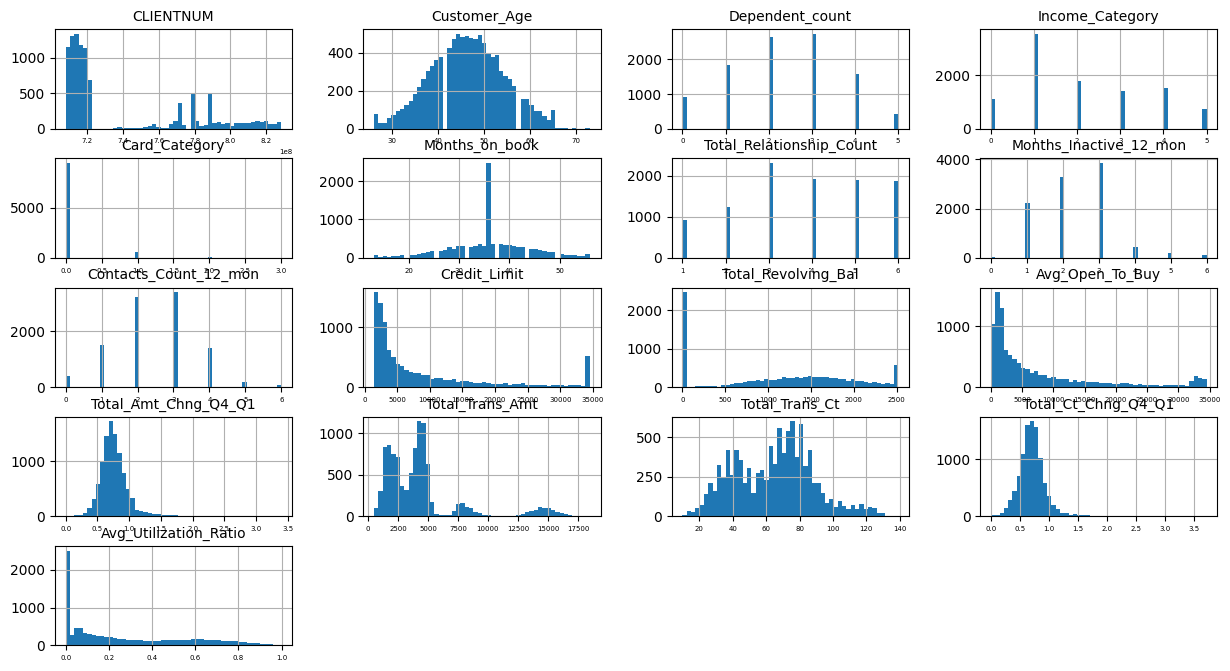

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=10)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=5)
plt.rc('ytick', labelsize=10)

df.hist(bins=50, figsize=(15, 8))

plt.savefig('histograms.png')
plt.show()


Es notable la presencia de Heavytails, como en el caso de Card categori, donde es ranosable que la mayoria de clientes tengan categoria 'Blue', Además de que en Months_on_book vemos que la mayoria(una cantidad destacable) de clientes cuenta con una antiguedad  de 35 meses -> casi 3 años (en este sentido, es impórtante preguntarse que causó ese acercamiento al banco)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#Preprocesamiento para ML

Se crea un pipelin con la intención de trabajar con las distribuciones del dataset y con las variables categoricas.

In [ ]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_selector, make_column_transformer
import numpy as np

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore') # Para variables categoricas
)

# aplicamos FunctionTransformer(np.log1p) antes del StandardScaler() para las variables con distribuciones no normales
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler()
)

In [ ]:
preprocessing = make_column_transformer(
    (cat_pipeline, make_column_selector(dtype_include=object)),
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    remainder='drop'
) #ensamblado de los pipelines

In [ ]:
from sklearn import set_config

set_config(display='diagram')

preprocessing

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a49e8b30>),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a4c89eb0>)])

In [ ]:
X_train_prepared = preprocessing.fit_transform(X_train)

#Modelos candidatos

Dada la neturaleza del problema, es importante definir las metricas a tener en cuenta para el correcto desarrollo del problema. En este caso, como los datos están desbalanceados, haremos uso del Recall(Exhaustividad) y ROC-AUC para la medición de exito.
Se pondran a prueba 3 modelos:

*   Regresiónl logistica
*   Random Forest
*   XGboost



In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import make_scorer, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:
# Mapeamos la variable objetivo para Entrenamiento y Prueba
# 1 = Fuga (Lo que nos interesa predecir)
# 0 = Se queda (El comportamiento normal)

diccionario_target = {
    'Attrited Customer': 1,
    'Existing Customer': 0
}

# Aplicamos el cambio
y_train = y_train.map(diccionario_target)
y_test = y_test.map(diccionario_target)

# Verificamos rápidamente que ya no haya texto
print("Valores únicos en y_train:", y_train.unique())

Valores únicos en y_train: [0 1]


##Regression logistica

In [ ]:
Logistic_regresion = make_pipeline(preprocessing,LogisticRegression(max_iter=1000, random_state=42))
log_params = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

buscador = GridSearchCV(
        estimator=Logistic_regresion,
        param_grid=log_params,
        cv=5,
        scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'},
        refit='ROC_AUC',
        n_jobs=-1
    )

print("Entrenando y optimizando ...")
buscador.fit(X_train, y_train)

Entrenando y optimizando ...


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a49e8b30>),
                                                                        ('pipeline-2',
                                                                         Pipeline(s...
                                                                                                              func=<ufunc 'log1p'>)),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a4c89eb0>)])),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100,
                                                   1000]},
             refit='ROC_AUC',
             scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'})

In [ ]:
indice_ganador = buscador.best_index_

# Extraemos el ROC_AUC y Recall de esa combinación específica
mejor_roc = buscador.cv_results_['mean_test_ROC_AUC'][indice_ganador]
mejor_recall = buscador.cv_results_['mean_test_Recall'][indice_ganador]
# 3. CREAR Y MOSTRAR LA TABLA
print(f"\nMejores parámetros: {buscador.best_params_}")
print(f"Mejor ROC-AUC: {round(mejor_roc,2)}")
print(f"Mejor Recall: {round(mejor_recall,2)}")


Mejores parámetros: {'logisticregression__C': 100}
Mejor ROC-AUC: 0.93
Mejor Recall: 0.59


##RandomForest

In [ ]:
Random_forest_pipeline = make_pipeline(preprocessing, RandomForestClassifier(random_state=42))
rf_params = {
    'randomforestclassifier__n_estimators': [100, 200, 300],
    'randomforestclassifier__max_depth': [None, 10, 20, 30]
}

buscador = GridSearchCV(
        estimator=Random_forest_pipeline,
        param_grid=rf_params,
        cv=5,
        scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'},
        refit='ROC_AUC',
        n_jobs=-1
    )

print("Entrenando y optimizando ...")
buscador.fit(X_train, y_train)

Entrenando y optimizando ...


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a49e8b30>),
                                                                        ('pipeline-2',
                                                                         Pipeline(s...
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a4c89eb0>)])),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [None, 10, 20,
                                                               30],
                         'randomforestclassifier__n_estimators': [100, 200,
                                                                  300]},
             refit='ROC_AUC',
             scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'})

In [ ]:
indice_ganador = buscador.best_index_

# Extraemos el ROC_AUC y Recall de esa combinación específica
mejor_roc = buscador.cv_results_['mean_test_ROC_AUC'][indice_ganador]
mejor_recall = buscador.cv_results_['mean_test_Recall'][indice_ganador]
# 3. CREAR Y MOSTRAR LA TABLA
print(f"\nMejores parámetros: {buscador.best_params_}")
print(f"Mejor ROC-AUC: {round(mejor_roc,2)}")
print(f"Mejor Recall: {round(mejor_recall,2)}")


Mejores parámetros: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 300}
Mejor ROC-AUC: 0.99
Mejor Recall: 0.79


## XGboost

In [ ]:
XGboost = make_pipeline(preprocessing, XGBClassifier(random_state=42))
xgb_params = {
        'xgbclassifier__n_estimators': [100, 200], # Cantidad de árboles
        'xgbclassifier__learning_rate': [0.01, 0.1], # Velocidad de aprendizaje
        'xgbclassifier__max_depth': [3, 5]           # Profundidad máxima
    }

buscador = GridSearchCV(
        estimator=XGboost,
        param_grid=xgb_params,
        cv=5,
        scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'},
        refit='ROC_AUC',
        n_jobs=-1
    )

print("Entrenando y optimizando ...")
buscador.fit(X_train, y_train)

Entrenando y optimizando ...


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a49e8b30>),
                                                                        ('pipeline-2',
                                                                         Pipeline(s...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgbclassifier__learning_rate': [0.01, 0.1],
                         'xgbclassifier__max_depth': [3, 5],
                         'xgbclassifier__n_estimators': [100, 200]},
             refit='ROC_AUC',
             scoring={'ROC_AUC': 'roc_auc', 'Recall': 'recall'})

In [ ]:
indice_ganador = buscador.best_index_

# Extraemos el ROC_AUC y Recall de esa combinación específica
mejor_roc = buscador.cv_results_['mean_test_ROC_AUC'][indice_ganador]
mejor_recall = buscador.cv_results_['mean_test_Recall'][indice_ganador]
# 3. CREAR Y MOSTRAR LA TABLA
print(f"\nMejores parámetros: {buscador.best_params_}")
print(f"Mejor ROC-AUC: {round(mejor_roc,2)}")
print(f"Mejor Recall: {round(mejor_recall,2)}")


Mejores parámetros: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 200}
Mejor ROC-AUC: 0.99
Mejor Recall: 0.89


Podemos concluir entonces que el modelo más preciso en el entrenamiento fue el XGboost, sin embargo, hay que recordar que también es el más pesado, lo cual puede ser un punto a tener en cuenta en producción por lo que puede considerarse usar el random forest , sin embargo, como esto es un ejercicio para repasar conceptos, se tomará al XGboost como ganador indiscutible

## Examen

Modelo Evaluado:     GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7b83a49e8b30>),
                                                                        ('pipeline-2',
                                                                         Pipeline(s...


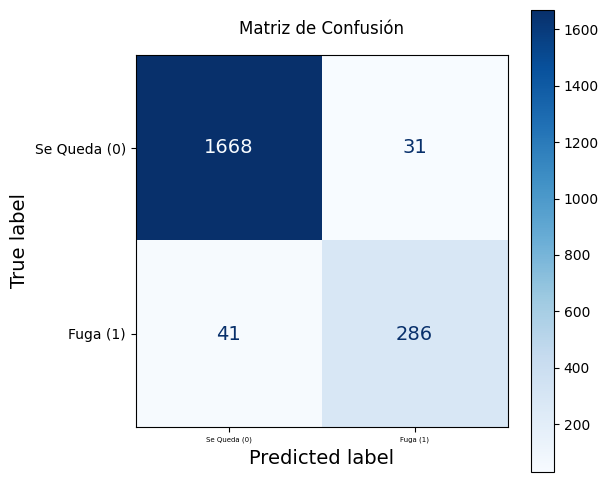

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, recall_score

# ========================================================
# 1. HACER LAS PREDICCIONES DEL MUNDO REAL
# ========================================================
# El modelo ganador (GridSearchCV) usa automáticamente su mejor versión.
y_pred = buscador.predict(X_test)
y_pred_proba = buscador.predict_proba(X_test)[:, 1] # Probabilidades para el ROC

# ========================================================
# 2. CALCULAR LAS MÉTRICAS EN EL SET DE PRUEBA
# ========================================================
test_roc = roc_auc_score(y_test, y_pred_proba)
test_recall = recall_score(y_test, y_pred)

print(f"Modelo Evaluado:     {buscador}")
print(f"ROC-AUC en Test:     {test_roc:.4f}  (En Validación fue: {mejor_roc:.4f})")
print(f"Recall en Test:      {test_recall:.4f}")
print("-" * 60)

# ========================================================
# 3. REPORTE DE CLASIFICACIÓN DETALLADO
# ========================================================
print("\nReporte de Clasificación Completo:")
print(classification_report(y_test, y_pred, target_names=['Se Queda (0)', 'Fuga (1)']))

# ========================================================
# 4. GRAFICAR LA MATRIZ DE CONFUSIÓN
# ========================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se Queda (0)', 'Fuga (1)'])

# Le damos un diseño limpio y elegante
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"Matriz de Confusión", fontsize=12, pad=15)
plt.grid(False)
plt.show()

# Analisis de posibles causales

In [ ]:
!pip install shap

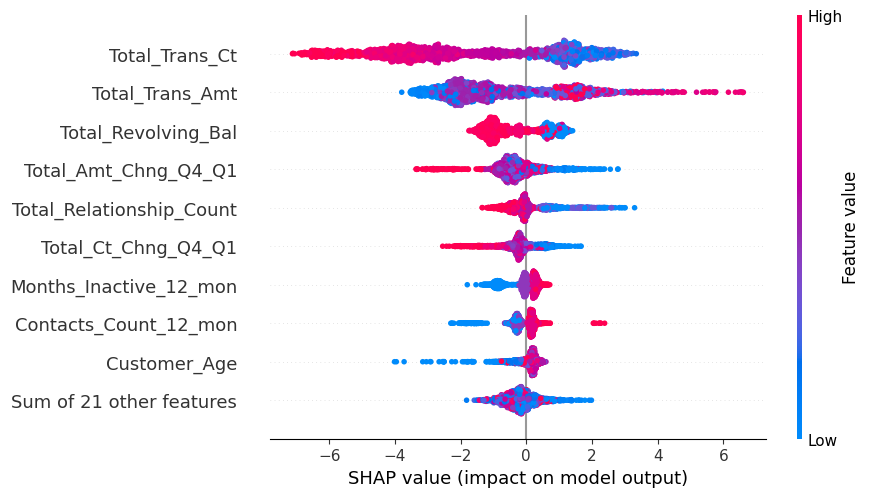

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Desarmamos el pipeline ganador para extraer el modelo y el preprocesador
pipeline_ganador = buscador.best_estimator_
preprocesador = pipeline_ganador.named_steps['columntransformer']
modelo_xgb = pipeline_ganador.named_steps['xgbclassifier']

# Convertimos los datos de prueba usando SOLO el preprocesador
# Esto es necesario porque SHAP necesita ver los datos exactamente como los vio XGBoost
X_test_transformado = preprocesador.transform(X_test)

# Reconstruimos los nombres de las columnas para que la gráfica sea legible
nombres_columnas = preprocesador.get_feature_names_out()
nombres_columnas_limpios = [n.split('__')[-1] for n in nombres_columnas]

# Creamos un DataFrame limpio con los nombres reales de las variables
X_test_prepared_df = pd.DataFrame(X_test_transformado, columns=nombres_columnas_limpios)

# Creamos el explicador de SHAP optimizado para árboles (TreeExplainer
explicador = shap.TreeExplainer(modelo_xgb)
valores_shap = explicador(X_test_prepared_df)

# Dibujamos el gráfico "Beeswarm" (Gráfico de Enjambre)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(valores_shap, max_display=10)
plt.show()

vemos que:
* Total_Trans_Ct(Cantidad Total de Transacciones) -> Clientes que usan muy poco su tarjeta son los que tienen más riesgo de irse
* Total_Revolving_Bal (Deuda que genera intereses) -> Si el cliente no tiene deuda, no tiene razones para seguir en el banco
* Months_Inactive_12_mon (Meses Inactivos) -> El cliente muestra una inactividad, señal de alerta
* Contacts_Count_12_mon (Contactos con el banco) -> El cliente tiene mucho contacto, lo más probable sea para quejarse


#Conclusiones

El modelo ha detectado que la fuga no ocurre de un día para otro. Es un proceso de 'enfriamiento'. El cliente típico que abandona el banco primero deja de usar la tarjeta para sus compras diarias (Total_Trans_Ct bajo), luego liquida cualquier deuda que tenga pendiente (Total_Revolving_Bal bajo), entra en un periodo de inactividad (Months_Inactive) y, si se ha tenido que comunicar repetidas veces con el banco (Contacts_Count alto), termina cancelando la cuenta definitivamente.